In [1]:
import pandas as pd 
import numpy as np 
import joblib


In [2]:
import pandas as pd 
import numpy as np 
import joblib


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,f1_score

In [4]:
df=pd.read_csv('HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.dtypes


Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

C:\Users\nithi\AppData\Local\Temp\ipykernel_27768\3733254561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Blues')


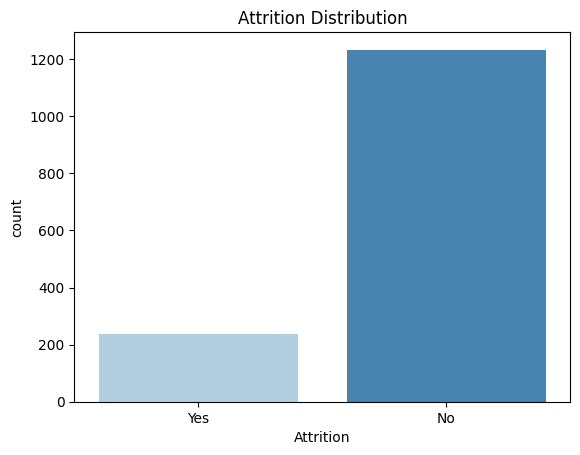

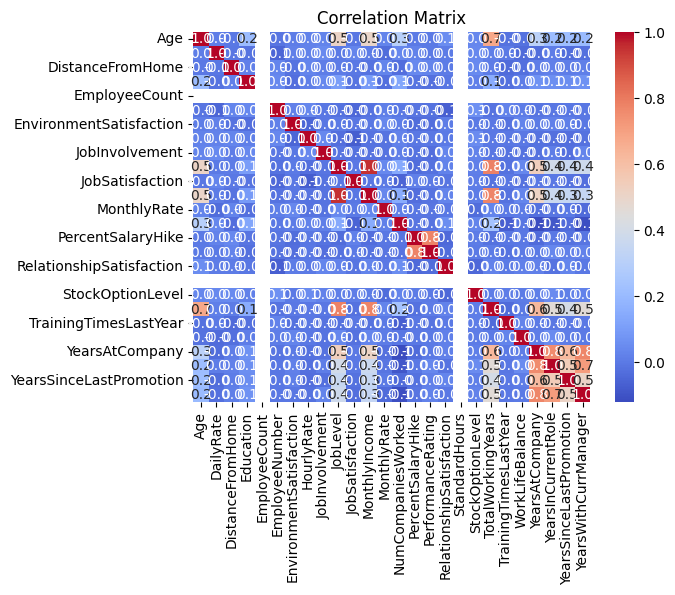

In [10]:
# Attrition distribution
sns.countplot(x='Attrition', data=df, palette='Blues')
plt.title('Attrition Distribution')
plt.show()

# Correlation heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Matrix')
plt.show()

In [11]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']

In [12]:
num_col=x.select_dtypes(exclude=object).columns
cat_col=x.select_dtypes(include=object).columns

C:\Users\nithi\AppData\Local\Temp\ipykernel_27768\2865430554.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=x.select_dtypes(include=object).columns


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
scaler=StandardScaler()
x_train[num_col]=scaler.fit_transform(x_train[num_col])
x_train[num_col]

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1097,-1.388559,-1.108139,1.440396,-0.863356,0.0,0.860666,0.279706,-0.472832,-1.012340,-0.932274,...,-0.639822,0.0,2.547471,-1.167368,0.157319,0.357435,-0.974263,-0.888208,-0.676110,-1.142448
727,-2.040738,-1.263481,-0.522699,-0.863356,0.0,-0.026811,-0.639104,0.309374,0.389912,-0.932274,...,1.211176,0.0,-0.945525,-1.423397,-0.613546,0.357435,-1.138573,-1.165051,-0.676110,-1.142448
254,-0.845077,1.103647,1.317703,-0.863356,0.0,-1.118456,1.198515,-1.059487,0.389912,-0.025447,...,1.211176,0.0,0.218807,-0.143254,-0.613546,0.357435,-0.645643,-0.611364,-0.676110,-0.575084
1175,0.241886,-0.758001,0.336155,0.099933,0.0,1.030258,1.198515,-0.032841,0.389912,-0.025447,...,0.285677,0.0,-0.945525,-0.527297,0.157319,0.357435,-0.317023,-0.057676,-0.355244,-1.142448
1341,-0.627685,-1.204303,1.317703,0.099933,0.0,1.404019,-0.639104,1.091580,0.389912,-0.025447,...,-1.565321,0.0,0.218807,-0.143254,-0.613546,0.357435,0.504527,1.049700,-0.676110,-0.575084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,-0.192899,-0.121835,2.299251,0.099933,0.0,0.934760,-0.639104,-1.010599,1.792164,-0.025447,...,1.211176,0.0,1.383139,-0.143254,0.157319,-1.082099,0.504527,1.326544,1.249084,1.127009
1294,0.459279,-0.868960,-0.522699,0.099933,0.0,1.293702,-0.639104,0.896028,1.792164,-0.025447,...,-1.565321,0.0,-0.945525,-0.015240,0.157319,-2.521633,-0.645643,-0.611364,-0.355244,-0.575084
860,-1.605952,1.125839,-0.768086,1.063222,0.0,0.287676,0.279706,-0.912823,-1.012340,-0.932274,...,-0.639822,0.0,0.218807,-1.295383,1.699050,0.357435,-1.138573,-1.165051,-0.676110,-1.142448
1459,-0.845077,1.426662,0.458849,-0.863356,0.0,1.687221,1.198515,-1.010599,-1.012340,-0.025447,...,-1.565321,0.0,0.218807,-0.143254,-0.613546,0.357435,-0.481333,-0.334520,-0.676110,-0.291401


In [15]:
one=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
new_col=one.fit_transform(x_train[cat_col])
new_col
names=one.get_feature_names_out()
names
cat_df=pd.DataFrame(new_col,columns=names)
cat_df

,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1172,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1173,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1174,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [16]:
x_train_final=pd.concat([x_train[num_col].reset_index(drop=True),cat_df],axis=1)
x_train_final

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,-1.388559,-1.108139,1.440396,-0.863356,0.0,0.860666,0.279706,-0.472832,-1.012340,-0.932274,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,-2.040738,-1.263481,-0.522699,-0.863356,0.0,-0.026811,-0.639104,0.309374,0.389912,-0.932274,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,-0.845077,1.103647,1.317703,-0.863356,0.0,-1.118456,1.198515,-1.059487,0.389912,-0.025447,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.241886,-0.758001,0.336155,0.099933,0.0,1.030258,1.198515,-0.032841,0.389912,-0.025447,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,-0.627685,-1.204303,1.317703,0.099933,0.0,1.404019,-0.639104,1.091580,0.389912,-0.025447,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,-0.192899,-0.121835,2.299251,0.099933,0.0,0.934760,-0.639104,-1.010599,1.792164,-0.025447,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1172,0.459279,-0.868960,-0.522699,0.099933,0.0,1.293702,-0.639104,0.896028,1.792164,-0.025447,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1173,-1.605952,1.125839,-0.768086,1.063222,0.0,0.287676,0.279706,-0.912823,-1.012340,-0.932274,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1174,-0.845077,1.426662,0.458849,-0.863356,0.0,1.687221,1.198515,-1.010599,-1.012340,-0.025447,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [17]:
x_test[num_col]=scaler.fit_transform(x_test[num_col])
x_test[num_col]

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,-1.078036,0.129893,-0.495769,0.021222,0.0,0.790670,1.063191,1.090274,0.338643,-0.186894,...,1.116791,0.0,-0.880616,-0.778269,0.946230,0.267748,-0.370767,-0.085511,-0.420427,-0.406707
184,1.752819,0.682799,0.515549,-1.018667,0.0,-1.314646,1.063191,-0.296236,1.760942,-0.186894,...,0.189287,0.0,1.561848,-0.909695,0.149119,0.267748,-0.530365,-0.632035,-0.420427,-0.406707
1222,-1.530972,-1.457810,1.653281,-2.058556,0.0,1.213805,1.063191,-0.244884,-2.505956,-1.087663,...,0.189287,0.0,0.340616,-1.435395,-0.647992,0.267748,-1.009159,-1.178559,-0.698819,-1.216450
67,0.846945,1.329548,-0.242940,0.021222,0.0,-1.597888,-0.748856,-0.193531,0.338643,0.713875,...,0.189287,0.0,0.340616,1.718809,-0.647992,0.267748,-1.009159,-1.178559,-0.698819,-1.216450
220,-0.172162,1.474115,-0.495769,-1.018667,0.0,-1.221383,1.063191,-0.039475,0.338643,-0.186894,...,1.116791,0.0,-0.880616,0.535982,0.149119,1.601949,0.906017,1.827324,0.136355,0.672949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,-0.398631,-1.295489,-0.875014,0.021222,0.0,-0.388929,1.063191,-0.142179,0.338643,-0.186894,...,0.189287,0.0,-0.880616,-0.778269,1.743341,0.267748,-0.211169,0.187751,-0.420427,-0.136793
560,-0.398631,-1.642958,-0.116525,2.101000,0.0,-0.407927,-0.748856,-1.580041,0.338643,-0.186894,...,0.189287,0.0,0.340616,-0.646844,0.149119,0.267748,-1.168757,-1.178559,-0.698819,-1.216450
945,1.413116,1.286431,2.411770,0.021222,0.0,0.528153,1.063191,-1.015167,0.338643,1.614644,...,-0.738218,0.0,-0.880616,1.718809,-0.647992,0.267748,-0.689963,-0.632035,-0.420427,-0.676622
522,-0.058928,1.040413,0.136304,-1.018667,0.0,-0.511552,1.063191,0.884865,1.760942,-1.087663,...,-1.665723,0.0,-0.880616,-1.041120,-0.647992,0.267748,-1.009159,-1.178559,-0.698819,-1.216450


In [18]:
cat_col_convert=one.fit_transform(x_test[cat_col])
cat_col_convert
names=one.get_feature_names_out()
cat_df_test=pd.DataFrame(cat_col_convert,columns=names)
cat_df_test

,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
290,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
291,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
292,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [19]:


x_test_final=pd.concat([x_test[num_col].reset_index(drop=True),cat_df_test],axis=1)
x_test_final

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,-1.078036,0.129893,-0.495769,0.021222,0.0,0.790670,1.063191,1.090274,0.338643,-0.186894,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,1.752819,0.682799,0.515549,-1.018667,0.0,-1.314646,1.063191,-0.296236,1.760942,-0.186894,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,-1.530972,-1.457810,1.653281,-2.058556,0.0,1.213805,1.063191,-0.244884,-2.505956,-1.087663,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.846945,1.329548,-0.242940,0.021222,0.0,-1.597888,-0.748856,-0.193531,0.338643,0.713875,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,-0.172162,1.474115,-0.495769,-1.018667,0.0,-1.221383,1.063191,-0.039475,0.338643,-0.186894,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,-0.398631,-1.295489,-0.875014,0.021222,0.0,-0.388929,1.063191,-0.142179,0.338643,-0.186894,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
290,-0.398631,-1.642958,-0.116525,2.101000,0.0,-0.407927,-0.748856,-1.580041,0.338643,-0.186894,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
291,1.413116,1.286431,2.411770,0.021222,0.0,0.528153,1.063191,-1.015167,0.338643,1.614644,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
292,-0.058928,1.040413,0.136304,-1.018667,0.0,-0.511552,1.063191,0.884865,1.760942,-1.087663,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [20]:
model=LogisticRegression()


In [21]:
print(model.fit(x_train_final, y_train))
y_pred = model.predict(x_test_final)
y_pred

LogisticRegression()


array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No',
       'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No',
       'No', 'No', 'No', 'No', 'No', 'Yes

In [22]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
print("Recall   :", recall_score(y_test, y_pred, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='Yes'))

Accuracy : 0.8843537414965986
Precision: 0.5757575757575758
Recall   : 0.48717948717948717
F1 Score : 0.5277777777777778


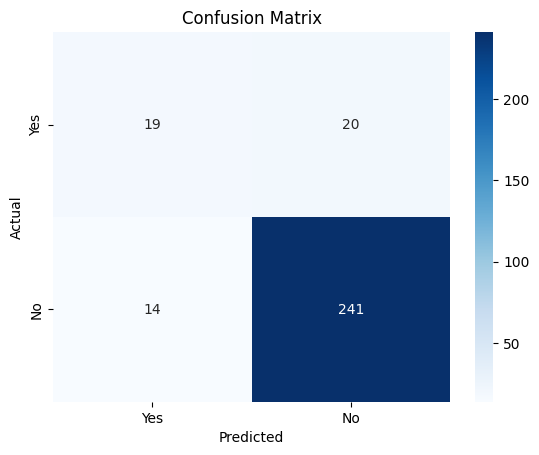

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=['Yes', 'No'])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Yes', 'No'],
    yticklabels=['Yes', 'No']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

C:\Users\nithi\AppData\Local\Temp\ipykernel_27768\2689496491.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


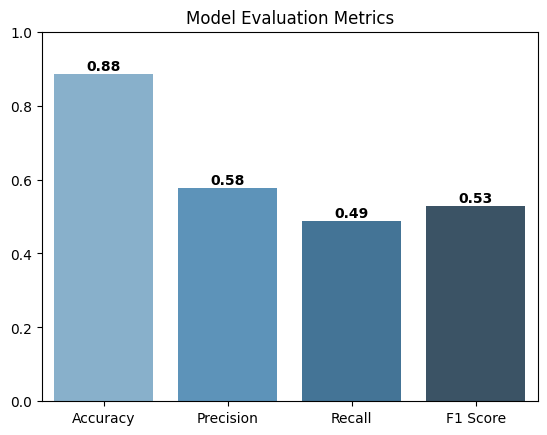

In [24]:
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, pos_label='Yes'),
    'Recall'   : recall_score(y_test, y_pred, pos_label='Yes'),
    'F1 Score' : f1_score(y_test, y_pred, pos_label='Yes')
}

sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values()),
    palette='Blues_d'
)

plt.title('Model Evaluation Metrics')
plt.ylim(0, 1)

for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

In [25]:


# Pack everything into one dictionary
artifacts = {
    'model'   : model,
    'scaler'  : scaler,
    'encoder' : one,
    'num_cols': num_col,
    'cat_cols': cat_col
}

# Dump as single file
joblib.dump(artifacts, 'artifacts.pkl')

print("Saved as single file — artifacts.pkl ✅")

Saved as single file — artifacts.pkl ✅
